# MNIST

In [209]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from array import array
from os.path  import join
from mnist import MNIST
from sklearn.model_selection import train_test_split

from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.manifold import LocallyLinearEmbedding
import umap

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

In [210]:
def plot_grid(results, y, titles):
    """
    results: list of (X_2d embeddings)
    y: labels
    titles: names of methods
    """

    n = len(results)
    cols = 3
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(8 * cols, 8 * rows))

    for i, (X_emb, title) in enumerate(zip(results, titles)):
        plt.subplot(rows, cols, i + 1)
        plt.scatter(X_emb[:, 0], X_emb[:, 1],
                    c=y, cmap="tab10", s=15, alpha=0.4)
        plt.title(title)
        plt.colorbar()
        plt.xticks([])
        plt.yticks([])

    plt.tight_layout()
    plt.show()

## MNIST load

In [211]:
mndata = MNIST('../data/')
mndata.gz = False

images, labels = mndata.load_training()
test_images, test_labels = mndata.load_testing()

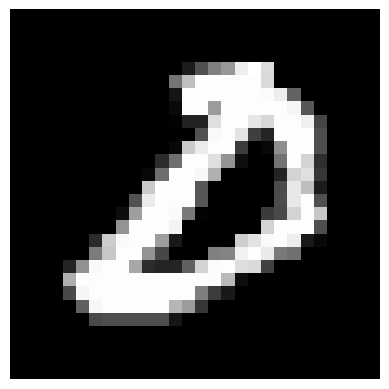

In [222]:
mnistX = np.array(images + test_images, dtype='float64')
mnistY = np.array(labels + test_labels)

mnistX = mnistX / 255.0
mnistY = mnistY.reshape(-1, 1)

# subset
np.random.seed(42)
idx = np.random.choice(a=70000, size = 10000)
mnistX = mnistX[idx, :]
mnistY = mnistY[idx]

# show image
some_digit = mnistX[0]
plt.imshow(some_digit.reshape(28, 28), cmap="gray")
plt.axis('off')
plt.show()

## PCA on MNIST

In [233]:
pca2 = PCA(n_components=2)
# mnist_pca2 = pca2.fit_transform(mnistX - mnistX.mean(axis=0))
mnist_pca2 = pca2.fit_transform(mnistX)

## SVD on MNIST

In [232]:
svd2 = TruncatedSVD(n_components=2)
# mnist_svd2 = svd2.fit_transform(mnistX - mnistX.mean(axis=0))
mnist_svd2 = svd2.fit_transform(mnistX)

## Randomized-SVD on MNIST

In [225]:
rsvd2 = TruncatedSVD(n_components=2, algorithm='randomized')
mnist_rsvd2 = rsvd2.fit_transform(mnistX)

## TSNE on MNIST

In [226]:
tsne2 = TSNE(n_components=2)
mnist_tsne2 = tsne2.fit_transform(mnistX)

## UMAP on MNIST

In [227]:
umap2 = umap.UMAP(n_components=2)
mnist_umap2 = umap2.fit_transform(mnistX)

## LLE on MNIST

In [228]:
lle2 = LocallyLinearEmbedding(n_components=2)
mnist_lle2 = lle2.fit_transform(mnistX)

## Drawing

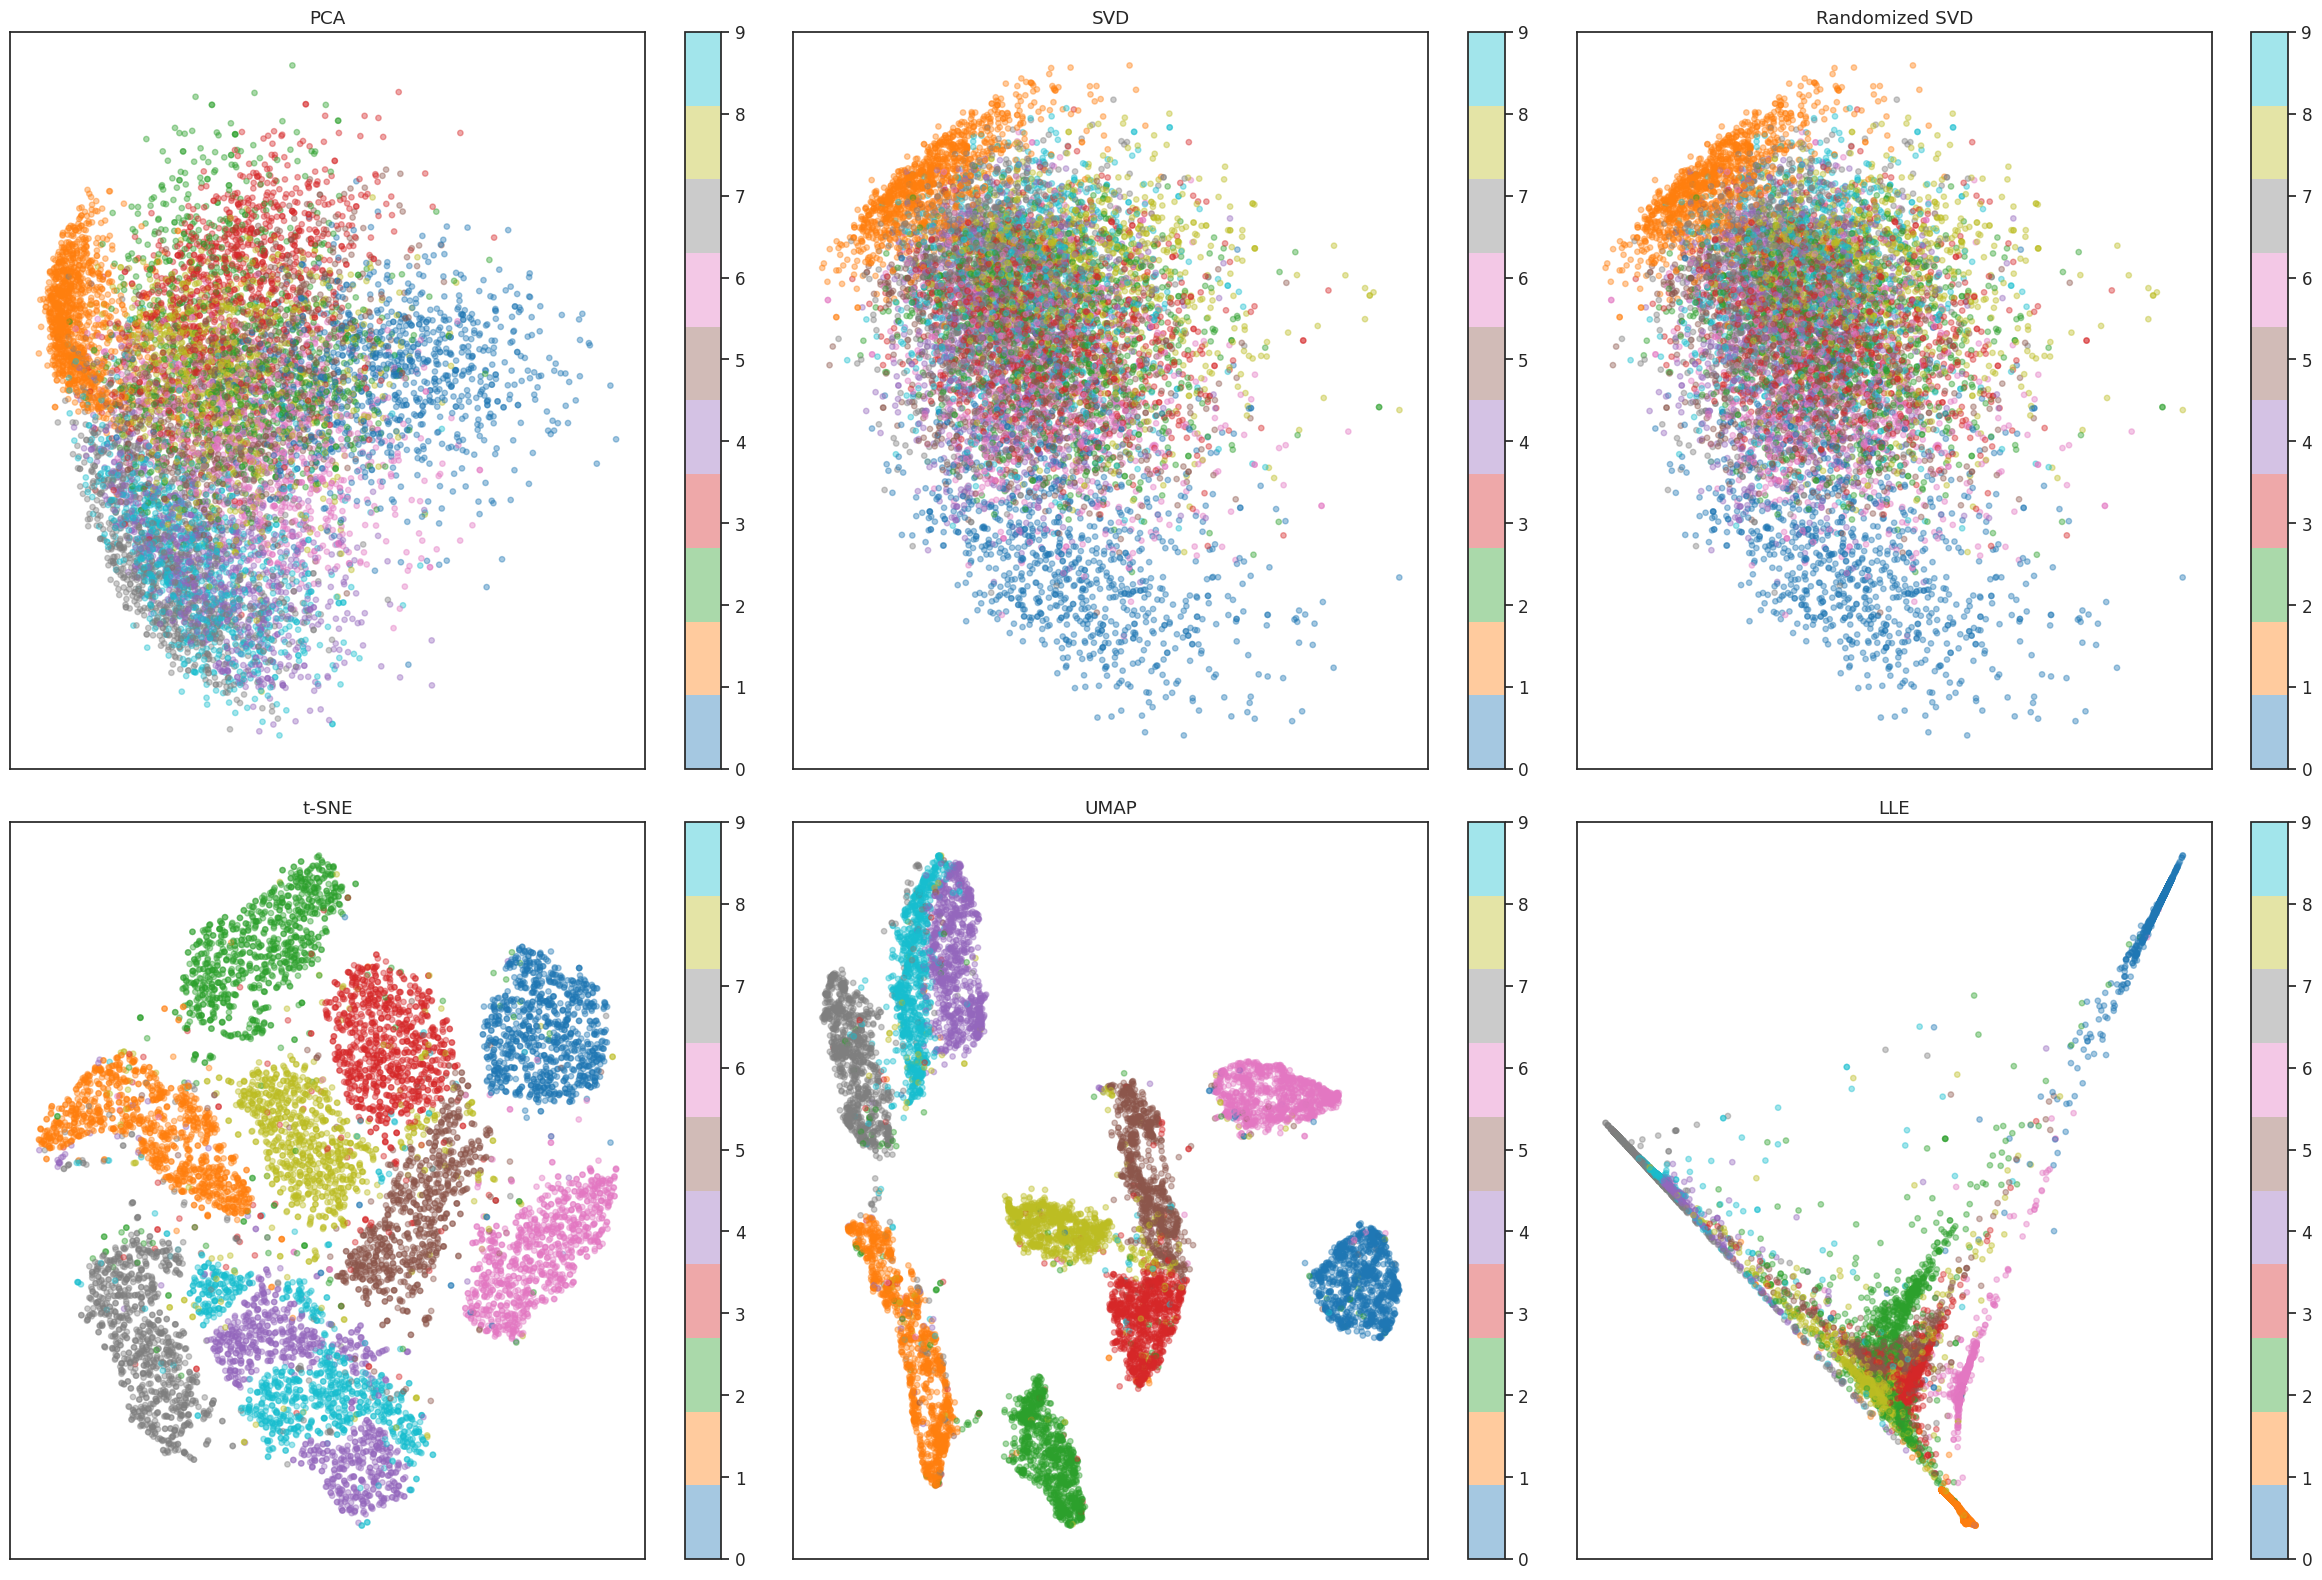

In [234]:
results = [
    mnist_pca2,
    mnist_svd2,
    mnist_rsvd2,
    mnist_tsne2,
    mnist_umap2,
    mnist_lle2
]

titles = [
    "PCA",
    "SVD",
    "Randomized SVD",
    "t-SNE",
    "UMAP",
    "LLE"
]

plot_grid(results, mnistY, titles)

## Metrics

In [237]:
mnistY = mnistY.ravel()

In [238]:
print("PCA:", silhouette_score(mnist_pca2, mnistY))
print("SVD:", silhouette_score(mnist_svd2, mnistY))
print("t-SNE:", silhouette_score(mnist_tsne2, mnistY))
print("UMAP:", silhouette_score(mnist_umap2, mnistY))
print("LLE:", silhouette_score(mnist_lle2, mnistY))

PCA: 0.024316547131723102
SVD: -0.032610417331873316
t-SNE: 0.3138750493526459
UMAP: 0.4061087965965271
LLE: 0.2612550332334059


In [239]:
print("PCA:", davies_bouldin_score(mnist_pca2, mnistY))
print("SVD:", davies_bouldin_score(mnist_svd2, mnistY))
print("t-SNE:", davies_bouldin_score(mnist_tsne2, mnistY))
print("UMAP:", davies_bouldin_score(mnist_umap2, mnistY))
print("LLE:", davies_bouldin_score(mnist_lle2, mnistY))

PCA: 5.989673770820113
SVD: 15.923217216422808
t-SNE: 2.658546451209579
UMAP: 1.1609431595658284
LLE: 3.0847175594072818
